In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option("display.max_columns",None)

In [7]:
sns.set_style("whitegrid")

In [8]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [9]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [10]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [11]:
df.shape

(1000, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df["Job"].unique()

array([2, 1, 3, 0])

In [17]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.dropna().reset_index(drop=True)

In [20]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [22]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

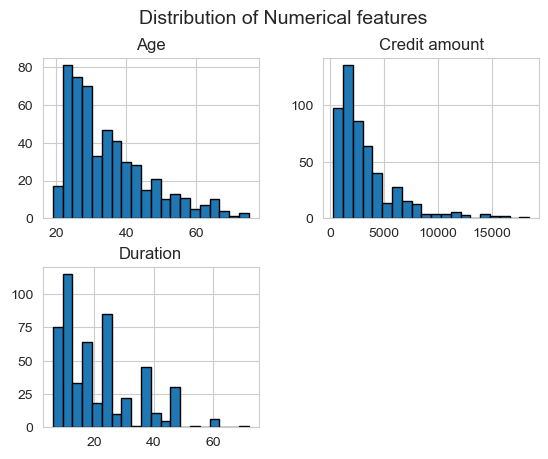

In [26]:
df[["Age","Credit amount","Duration"]].hist(bins=20,edgecolor="black")
plt.suptitle("Distribution of Numerical features", fontsize=14)
plt.show()

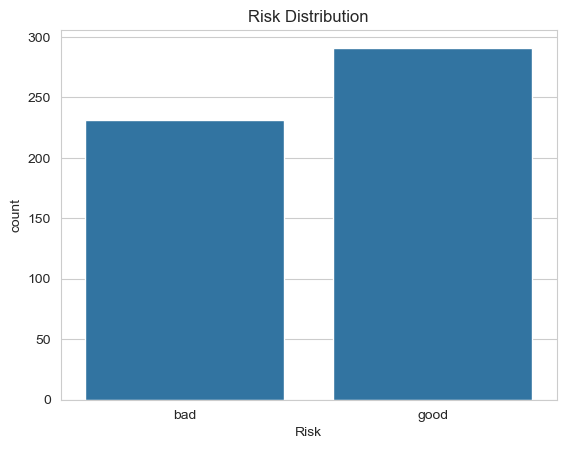

In [27]:
sns.countplot(data=df, x="Risk")
plt.title("Risk Distribution")
plt.show()

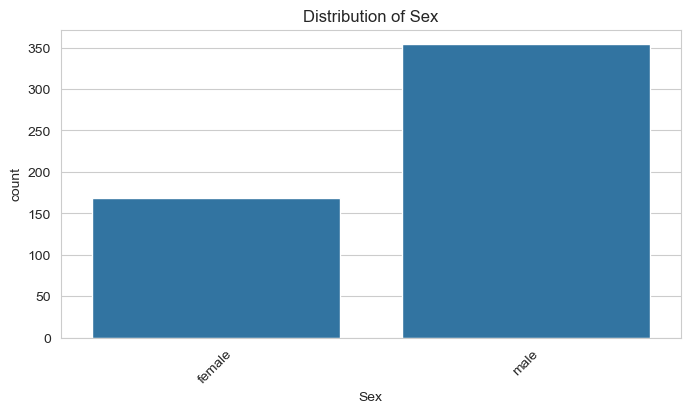

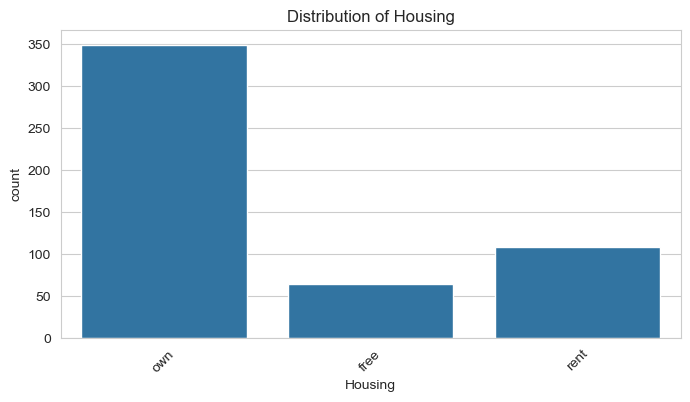

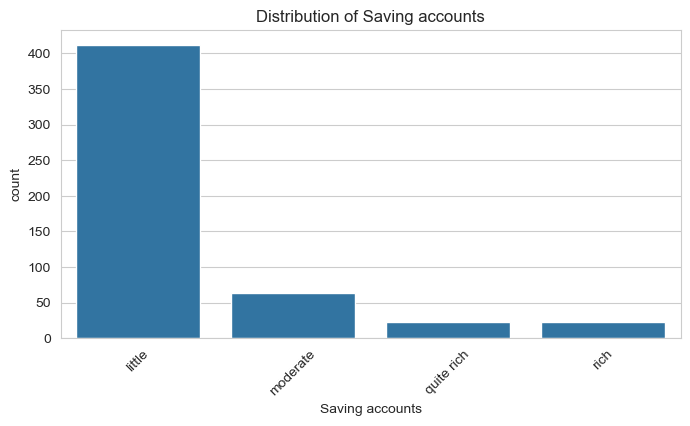

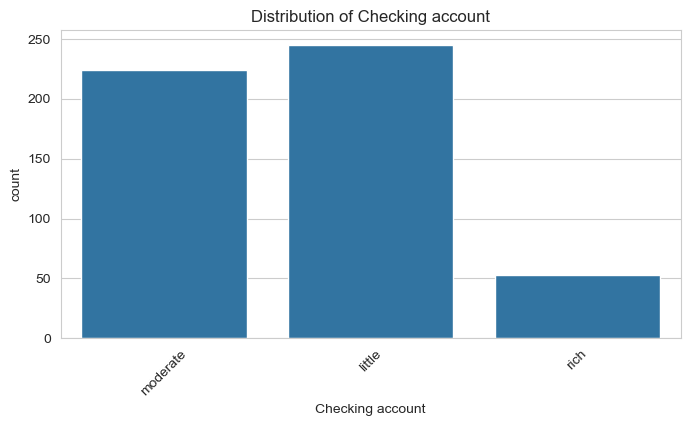

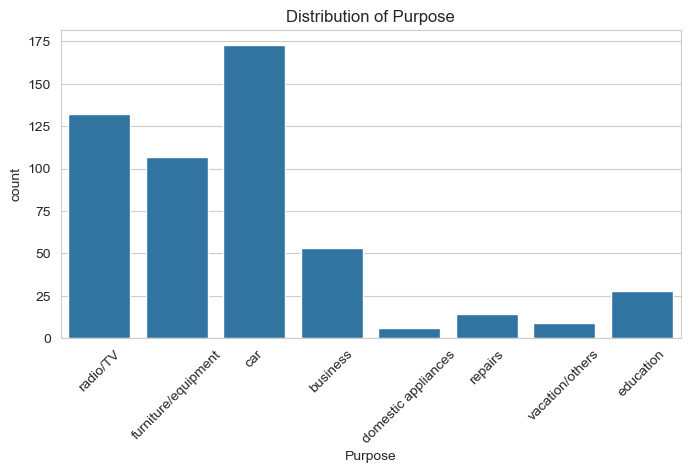

In [28]:
categorical_cols = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

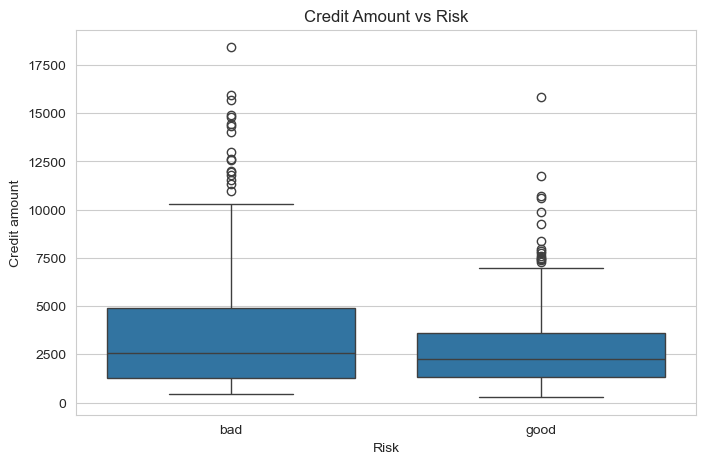

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Risk", y="Credit amount")
plt.title("Credit Amount vs Risk")
plt.show()

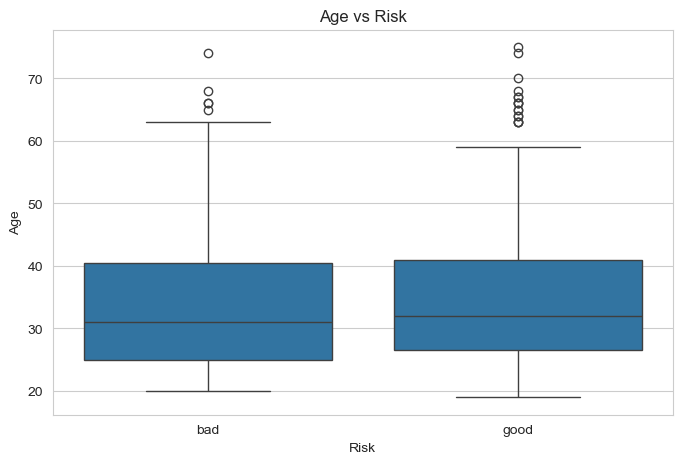

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Risk", y="Age")
plt.title("Age vs Risk")
plt.show()

In [31]:
features = [
    'Age',
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Credit amount',
    'Duration'
]

target = 'Risk'

df_model = df[features + [target]].copy()

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [32]:
from sklearn.preprocessing import LabelEncoder
import joblib

categorical_cols = [
    'Sex',
    'Housing',
    'Saving accounts',
    'Checking account'
]

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

    joblib.dump(le, f"{col}_encoder.pkl")

In [33]:
target_encoder = LabelEncoder()

df_model["Risk"] = target_encoder.fit_transform(df_model["Risk"])

joblib.dump(target_encoder, "target_encoder.pkl")

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [34]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Risk", axis=1)
y = df_model["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(417, 8)
(105, 8)


In [35]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [36]:
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6571428571428571


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.54      0.58        46
           1       0.68      0.75      0.71        59

    accuracy                           0.66       105
   macro avg       0.65      0.64      0.65       105
weighted avg       0.65      0.66      0.65       105



In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance

,Feature,Importance
6,Credit amount,0.246507
0,Age,0.226735
7,Duration,0.222487
2,Job,0.094209
5,Checking account,0.067800
3,Housing,0.059684
4,Saving accounts,0.051659
1,Sex,0.030918


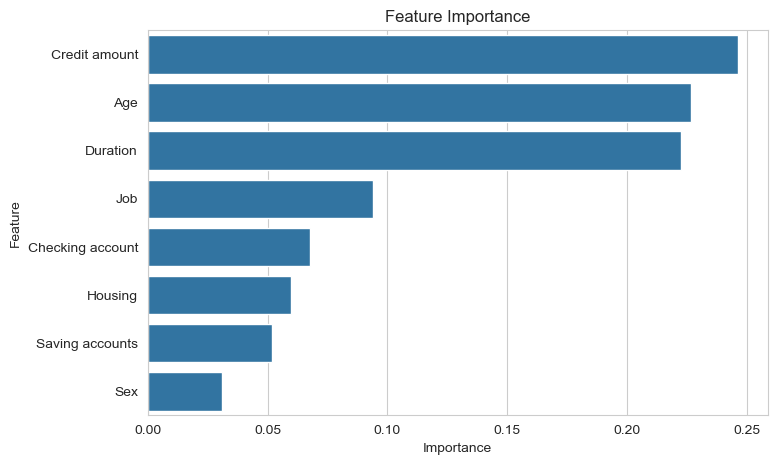

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [41]:
joblib.dump(model, "extra_trees_credit_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [42]:
print("Accuracy:", accuracy)

Accuracy: 0.6571428571428571


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.54      0.58        46
           1       0.68      0.75      0.71        59

    accuracy                           0.66       105
   macro avg       0.65      0.64      0.65       105
weighted avg       0.65      0.66      0.65       105



In [44]:
importance

,Feature,Importance
6,Credit amount,0.246507
0,Age,0.226735
7,Duration,0.222487
2,Job,0.094209
5,Checking account,0.067800
3,Housing,0.059684
4,Saving accounts,0.051659
1,Sex,0.030918


In [46]:
print(X.columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration'],
      dtype='object')


In [47]:
import os

os.path.exists("extra_trees_credit_model.pkl")

True

In [48]:
os.path.getsize("extra_trees_credit_model.pkl")

9253609

In [49]:
import joblib

model = joblib.load("extra_trees_credit_model.pkl")
print(model)

ExtraTreesClassifier(class_weight='balanced', n_estimators=200, random_state=1)


In [50]:
df["Sex"].unique()

array(['female', 'male'], dtype=object)

In [51]:
df["Housing"].unique()

array(['own', 'free', 'rent'], dtype=object)

In [52]:
df["Saving accounts"].unique()

array(['little', 'moderate', 'quite rich', 'rich'], dtype=object)

In [53]:
df["Checking account"].unique()

array(['moderate', 'little', 'rich'], dtype=object)